In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/taweilo/loan-approval-classification-data/loan_data.csv


In [2]:
df=pd.read_csv('/kaggle/input/datasets/taweilo/loan-approval-classification-data/loan_data.csv')
df

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22.0,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,No,1
1,21.0,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,Yes,0
2,25.0,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,No,1
3,23.0,female,Bachelor,79753.0,0,RENT,35000.0,MEDICAL,15.23,0.44,2.0,675,No,1
4,24.0,male,Master,66135.0,1,RENT,35000.0,MEDICAL,14.27,0.53,4.0,586,No,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
44995,27.0,male,Associate,47971.0,6,RENT,15000.0,MEDICAL,15.66,0.31,3.0,645,No,1
44996,37.0,female,Associate,65800.0,17,RENT,9000.0,HOMEIMPROVEMENT,14.07,0.14,11.0,621,No,1
44997,33.0,male,Associate,56942.0,7,RENT,2771.0,DEBTCONSOLIDATION,10.02,0.05,10.0,668,No,1
44998,29.0,male,Bachelor,33164.0,4,RENT,12000.0,EDUCATION,13.23,0.36,6.0,604,No,1


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45000 entries, 0 to 44999
Data columns (total 14 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   person_age                      45000 non-null  float64
 1   person_gender                   45000 non-null  object 
 2   person_education                45000 non-null  object 
 3   person_income                   45000 non-null  float64
 4   person_emp_exp                  45000 non-null  int64  
 5   person_home_ownership           45000 non-null  object 
 6   loan_amnt                       45000 non-null  float64
 7   loan_intent                     45000 non-null  object 
 8   loan_int_rate                   45000 non-null  float64
 9   loan_percent_income             45000 non-null  float64
 10  cb_person_cred_hist_length      45000 non-null  float64
 11  credit_score                    45000 non-null  int64  
 12  previous_loan_defaults_on_file  

In [4]:
df.describe()

,person_age,person_income,person_emp_exp,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,loan_status
count,45000.000000,4.500000e+04,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000
mean,27.764178,8.031905e+04,5.410333,9583.157556,11.006606,0.139725,5.867489,632.608756,0.222222
std,6.045108,8.042250e+04,6.063532,6314.886691,2.978808,0.087212,3.879702,50.435865,0.415744
min,20.000000,8.000000e+03,0.000000,500.000000,5.420000,0.000000,2.000000,390.000000,0.000000
25%,24.000000,4.720400e+04,1.000000,5000.000000,8.590000,0.070000,3.000000,601.000000,0.000000
50%,26.000000,6.704800e+04,4.000000,8000.000000,11.010000,0.120000,4.000000,640.000000,0.000000
75%,30.000000,9.578925e+04,8.000000,12237.250000,12.990000,0.190000,8.000000,670.000000,0.000000
max,144.000000,7.200766e+06,125.000000,35000.000000,20.000000,0.660000,30.000000,850.000000,1.000000


In [5]:
df.isnull().sum()

person_age                        0
person_gender                     0
person_education                  0
person_income                     0
person_emp_exp                    0
person_home_ownership             0
loan_amnt                         0
loan_intent                       0
loan_int_rate                     0
loan_percent_income               0
cb_person_cred_hist_length        0
credit_score                      0
previous_loan_defaults_on_file    0
loan_status                       0
dtype: int64

**No null entries.**

In [6]:
df.duplicated().sum()

np.int64(0)

**No duplicate entries.**

In [7]:
df.shape

(45000, 14)

In [8]:
df['loan_status'].value_counts()

loan_status
0    35000
1    10000
Name: count, dtype: int64

In [9]:
df['loan_status'].value_counts(normalize=True) * 100

loan_status
0    77.777778
1    22.222222
Name: proportion, dtype: float64

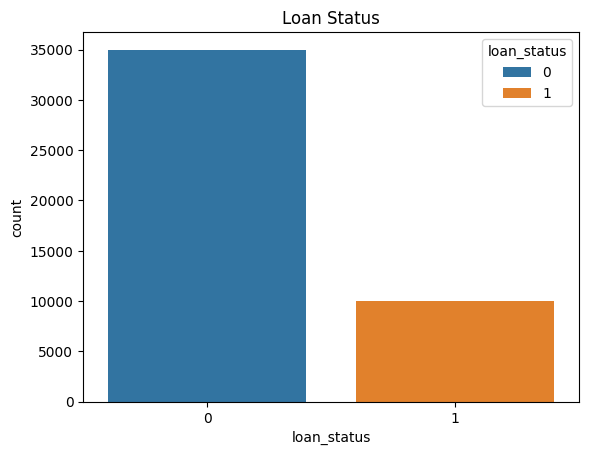

In [10]:
sns.countplot(data=df, x='loan_status',hue='loan_status')
plt.title('Loan Status')
plt.show()

In [11]:
df

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22.0,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,No,1
1,21.0,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,Yes,0
2,25.0,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,No,1
3,23.0,female,Bachelor,79753.0,0,RENT,35000.0,MEDICAL,15.23,0.44,2.0,675,No,1
4,24.0,male,Master,66135.0,1,RENT,35000.0,MEDICAL,14.27,0.53,4.0,586,No,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
44995,27.0,male,Associate,47971.0,6,RENT,15000.0,MEDICAL,15.66,0.31,3.0,645,No,1
44996,37.0,female,Associate,65800.0,17,RENT,9000.0,HOMEIMPROVEMENT,14.07,0.14,11.0,621,No,1
44997,33.0,male,Associate,56942.0,7,RENT,2771.0,DEBTCONSOLIDATION,10.02,0.05,10.0,668,No,1
44998,29.0,male,Bachelor,33164.0,4,RENT,12000.0,EDUCATION,13.23,0.36,6.0,604,No,1


In [12]:
cont_cols=['person_age','person_income','loan_amnt','loan_int_rate','loan_percent_income','cb_person_cred_hist_length','person_emp_exp',
           'credit_score']
cat_cols=['person_gender','person_education','person_home_ownership','loan_intent','previous_loan_defaults_on_file']
target=['loan_status']
print(cont_cols)
print(cat_cols)
print(target)

['person_age', 'person_income', 'loan_amnt', 'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length', 'person_emp_exp', 'credit_score']
['person_gender', 'person_education', 'person_home_ownership', 'loan_intent', 'previous_loan_defaults_on_file']
['loan_status']


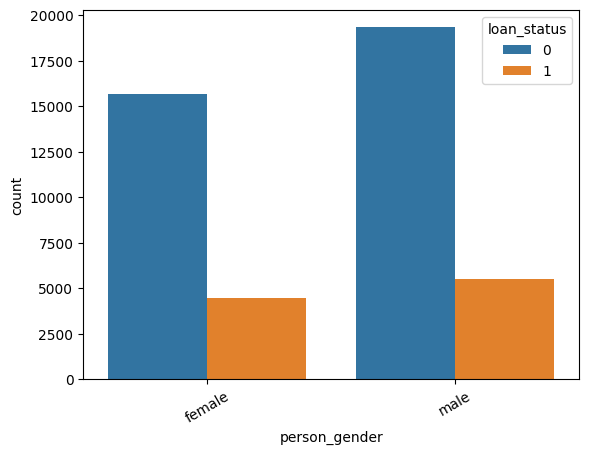

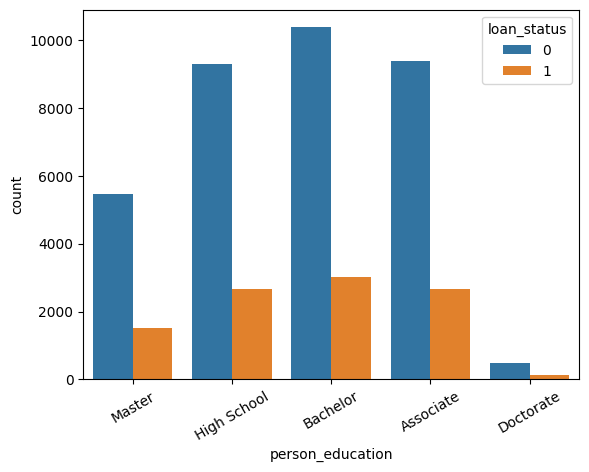

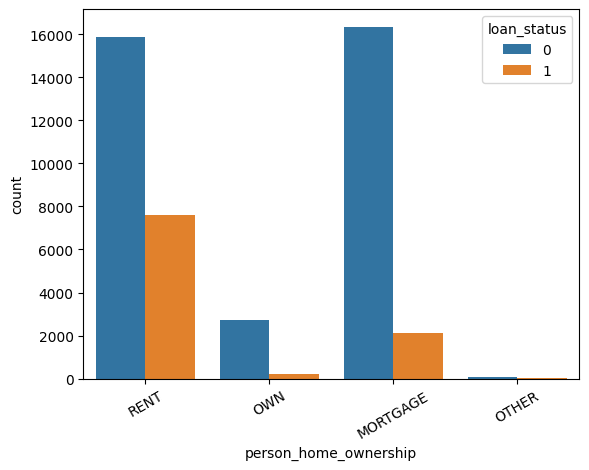

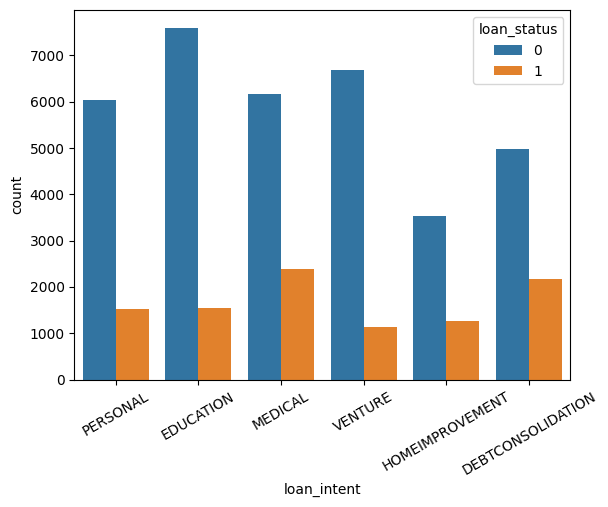

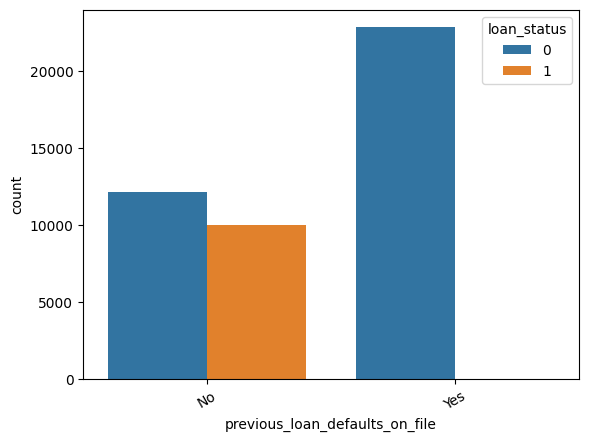

In [13]:
for col in cat_cols:
    sns.countplot(data=df,x=col, hue='loan_status')
    plt.xticks(rotation=30)
    plt.show()

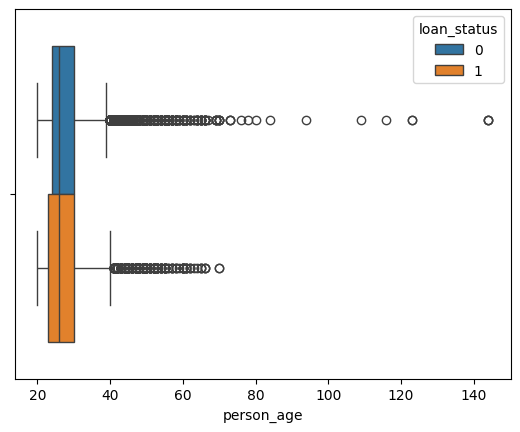

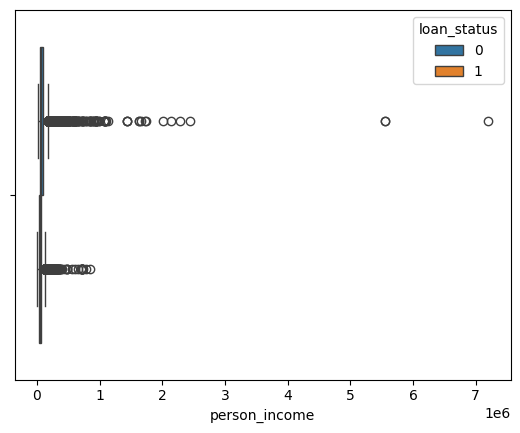

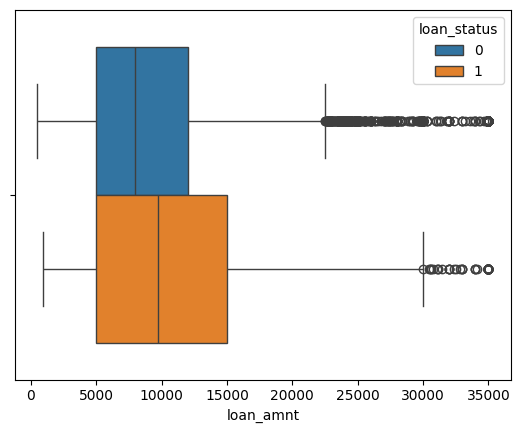

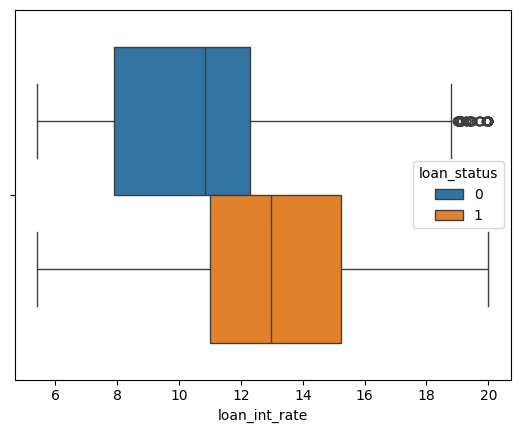

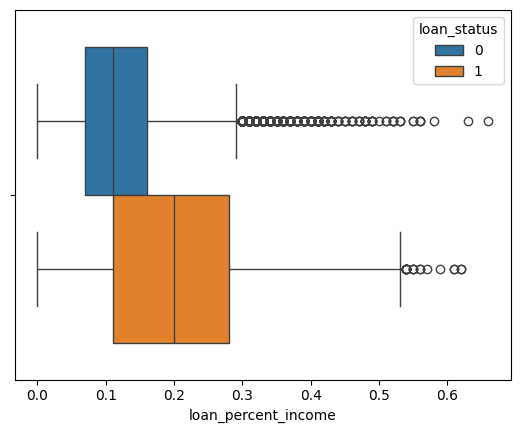

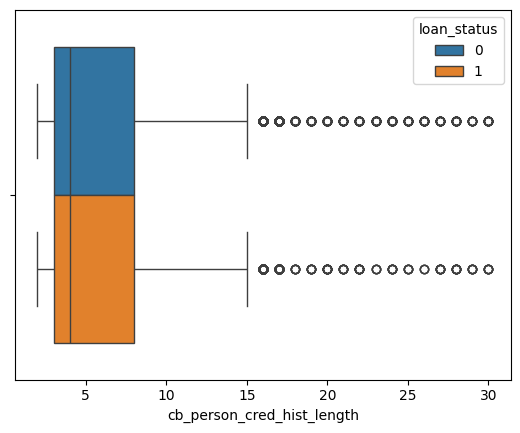

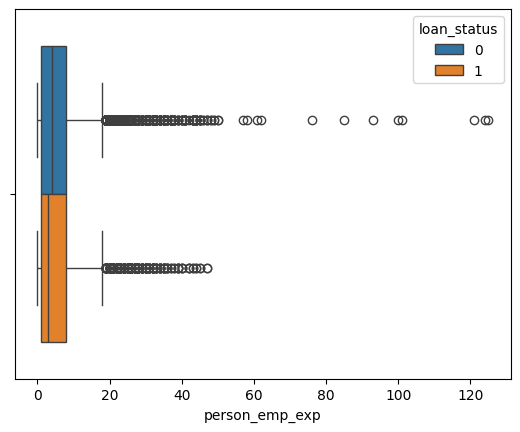

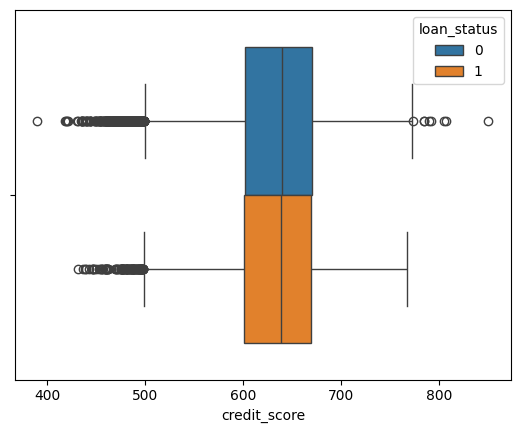

In [14]:
for cols in cont_cols:
    sns.boxplot(data=df,x=cols,hue='loan_status')
    plt.show()

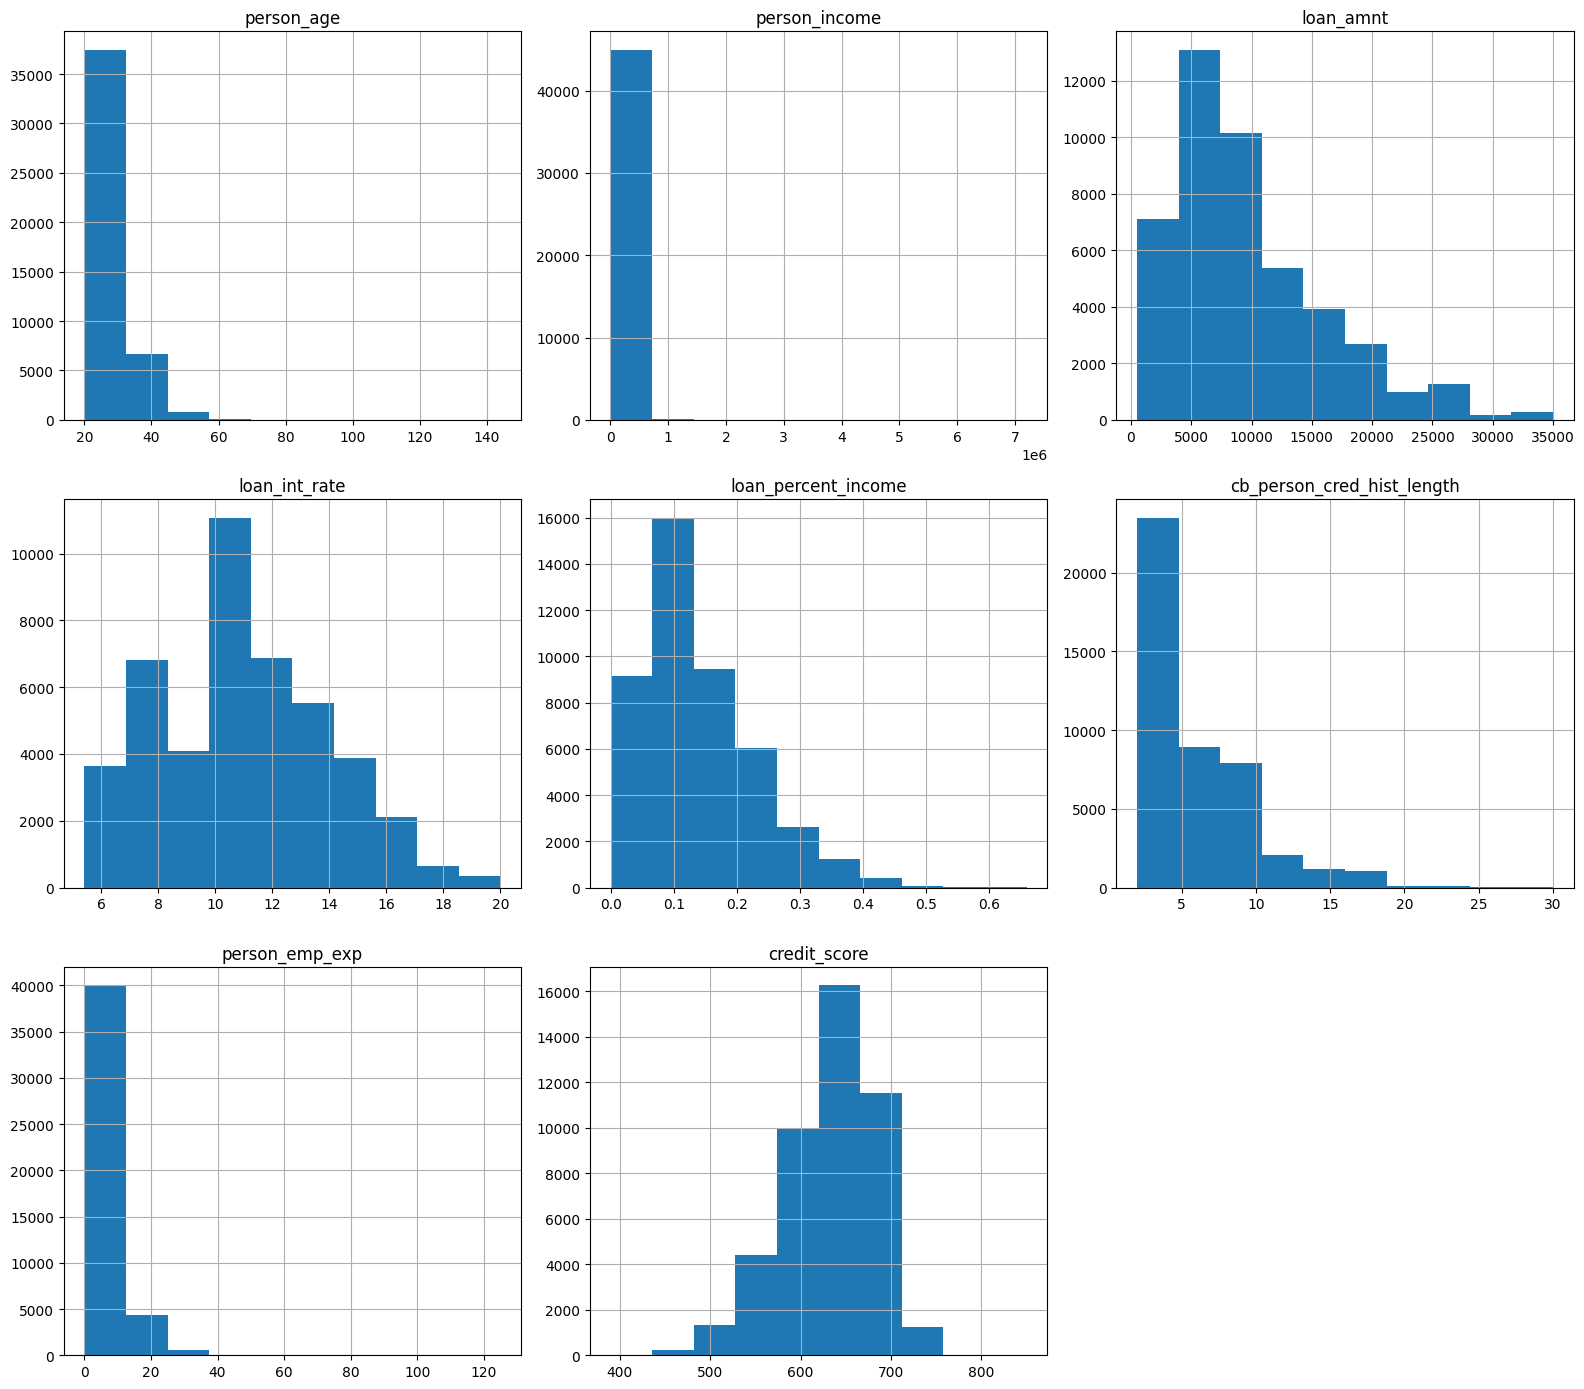

In [15]:
df[cont_cols].hist(figsize=(16,14))
plt.tight_layout()

In [16]:
df.skew(numeric_only=True)

person_age                     2.548154
person_income                 34.137583
person_emp_exp                 2.594917
loan_amnt                      1.179731
loan_int_rate                  0.213784
loan_percent_income            1.034512
cb_person_cred_hist_length     1.631720
credit_score                  -0.610261
loan_status                    1.336351
dtype: float64

In [17]:
df.kurt(numeric_only=True)

person_age                      18.649449
person_income                 2398.684769
person_emp_exp                  19.168324
loan_amnt                        1.351215
loan_int_rate                   -0.420335
loan_percent_income              1.082416
cb_person_cred_hist_length       3.725945
credit_score                     0.203022
loan_status                     -0.214176
dtype: float64

In [18]:
from scipy.stats import ttest_ind
features=['person_age', 'person_income', 'loan_amnt', 'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length', 'person_emp_exp', 
          'credit_score']
for feature in features:
    group0=df[df['loan_status']==0][feature]
    group1=df[df['loan_status']==1][feature]

    t_stat,p_value=ttest_ind(group0, group1)

    print(f"Feature: {feature}")
    print(f"t-statistic:{t_stat}")
    print(f"p-value:{p_value}\n")

Feature: person_age
t-statistic:4.55670891211329
p-value:5.20977352174543e-06

Feature: person_income
t-statistic:29.077927824499543
p-value:3.4830994169490465e-184

Feature: loan_amnt
t-statistic:-22.982898691889112
p-value:3.236704416270359e-116

Feature: loan_int_rate
t-statistic:-74.66226798171495
p-value:0.0

Feature: loan_percent_income
t-statistic:-88.45786584304646
p-value:0.0

Feature: cb_person_cred_hist_length
t-statistic:3.1505831673919937
p-value:0.00163051562774701

Feature: person_emp_exp
t-statistic:4.345546092915819
p-value:1.3923370134917003e-05

Feature: credit_score
t-statistic:1.6222224573775506
p-value:0.10476273051043743



**person_age, person_income, cb_person_cred_his_length, person_emp_exp show difference in their population means among the different categories. loan_amnt and loan_int_rate show a p-value very close to 0 which is then rounded to 0, this just means that they show a very strong and clear distinction in their means among the different categories.**

In [19]:
from scipy.stats import chi2_contingency
features=['person_gender','person_education','person_home_ownership','loan_intent','previous_loan_defaults_on_file']
for feature in features:
    table=pd.crosstab(df[feature],df['loan_status'])
    chi2,p_val,dof,expected=chi2_contingency(table)

    print(feature)
    print(f"Chi2-value:{chi2}")
    print(f"P-value:{p_val}\n")

person_gender
Chi2-value:0.011593759269277155
P-value:0.9142540404277906

person_education
Chi2-value:2.0159398837088074
P-value:0.732826935503778

person_home_ownership
Chi2-value:2989.5147066749823
P-value:0.0

loan_intent
Chi2-value:909.6476783138056
P-value:2.173084187054017e-194

previous_loan_defaults_on_file
Chi2-value:13270.28801071555
P-value:0.0



**person gender and person education have p values above 0.05 hemce null hypothesis is not rejected, the two features do not show any difference among the target categories. While the opposite remains trrue for  person home ownership, loan intent, previous loan defaults on file, have p value almost close to 0, this means that they show a very strong and clear distinction among the target variable categories.**

In [20]:
corr=df.corr(numeric_only=True)
corr['loan_status'].sort_values(ascending=False)

loan_status                   1.000000
loan_percent_income           0.384880
loan_int_rate                 0.332005
loan_amnt                     0.107714
credit_score                 -0.007647
cb_person_cred_hist_length   -0.014851
person_emp_exp               -0.020481
person_age                   -0.021476
person_income                -0.135808
Name: loan_status, dtype: float64

<Axes: >

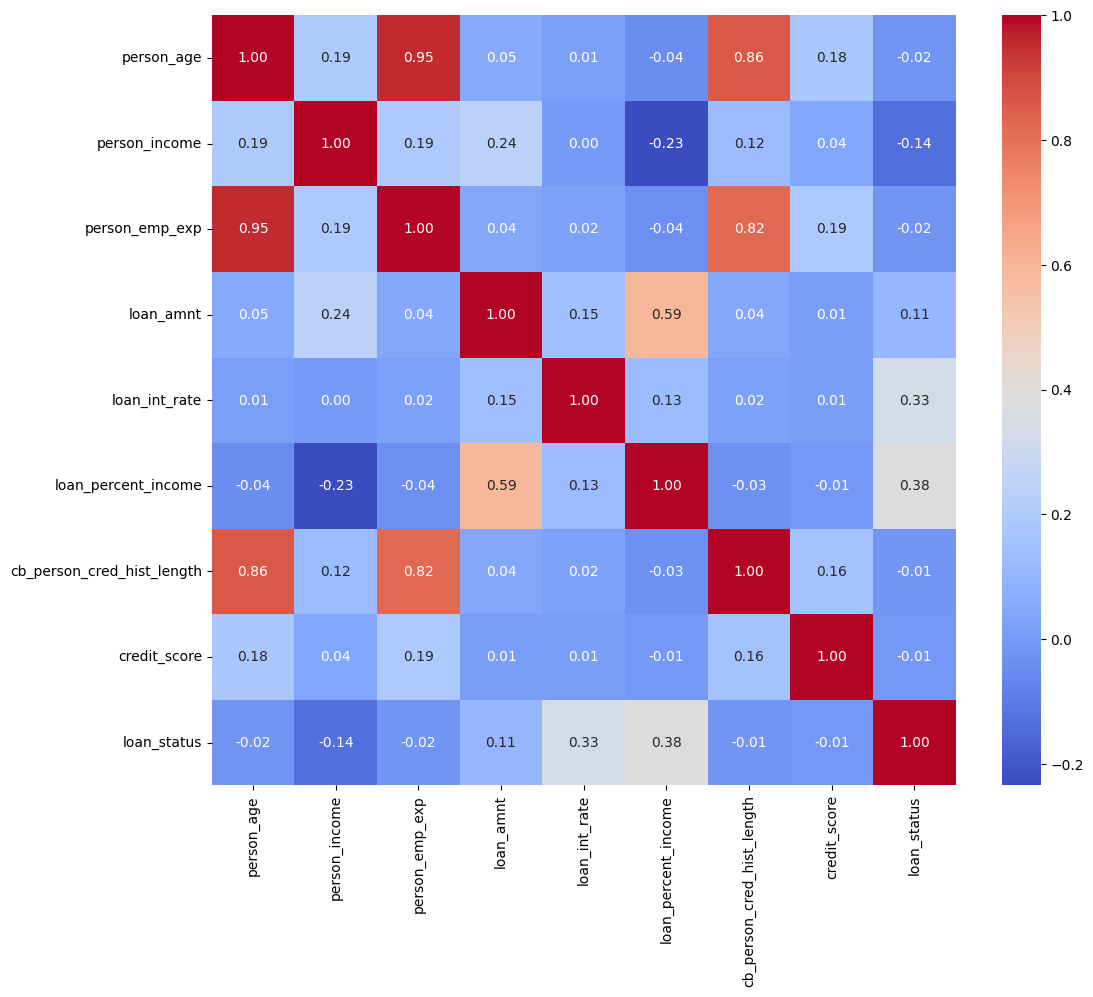

In [21]:
plt.figure(figsize=(12,10))
sns.heatmap(df.corr(numeric_only=True),annot=True, fmt=".2f",cmap='coolwarm')

**Here we either remove person age or person emp exp due to high collinearity between the two features, which can indirectly affect our KNN model.Hence, choosing one of the two, we choose person age.**

In [22]:
df.drop(columns='person_age', inplace=True)

In [23]:
print(df.columns)

Index(['person_gender', 'person_education', 'person_income', 'person_emp_exp',
       'person_home_ownership', 'loan_amnt', 'loan_intent', 'loan_int_rate',
       'loan_percent_income', 'cb_person_cred_hist_length', 'credit_score',
       'previous_loan_defaults_on_file', 'loan_status'],
      dtype='object')


In [24]:
columns=['person_income','loan_amnt','loan_int_rate','loan_percent_income','cb_person_cred_hist_length','person_emp_exp',
           'credit_score']

for col in columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3-Q1
    lower = Q1 - 1.5*IQR
    upper = Q3 + 1.5*IQR
    if lower<0:
        lower=0
    outliers = df[(df[col] < lower) | (df[col] > upper)]

    print(f"{col}")
    print(f"Normal range: {lower:.2f} to {upper:.2f}")
    print(f"Outliers: {len(outliers)} ({len(outliers)/len(df)*100:.2f}%)\n")

person_income
Normal range: 0.00 to 168667.12
Outliers: 2218 (4.93%)

loan_amnt
Normal range: 0.00 to 23093.12
Outliers: 2348 (5.22%)

loan_int_rate
Normal range: 1.99 to 19.59
Outliers: 124 (0.28%)

loan_percent_income
Normal range: 0.00 to 0.37
Outliers: 744 (1.65%)

cb_person_cred_hist_length
Normal range: 0.00 to 15.50
Outliers: 1366 (3.04%)

person_emp_exp
Normal range: 0.00 to 18.50
Outliers: 1724 (3.83%)

credit_score
Normal range: 497.50 to 773.50
Outliers: 467 (1.04%)



In [25]:
cat_cols=['person_gender','person_education','person_home_ownership','loan_intent','previous_loan_defaults_on_file']
for col in cat_cols:
    print(f"{col}: {df[col].nunique()} categories")

person_gender: 2 categories
person_education: 5 categories
person_home_ownership: 4 categories
loan_intent: 6 categories
previous_loan_defaults_on_file: 2 categories


In [26]:
from sklearn.preprocessing import LabelEncoder
label_encoder=LabelEncoder()
cols=['person_gender','previous_loan_defaults_on_file']
for col in cols:
    df[col]=label_encoder.fit_transform(df[col])

In [27]:
df=pd.get_dummies(df,columns=['person_education','person_home_ownership','loan_intent'],dtype=int)

In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45000 entries, 0 to 44999
Data columns (total 25 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   person_gender                   45000 non-null  int64  
 1   person_income                   45000 non-null  float64
 2   person_emp_exp                  45000 non-null  int64  
 3   loan_amnt                       45000 non-null  float64
 4   loan_int_rate                   45000 non-null  float64
 5   loan_percent_income             45000 non-null  float64
 6   cb_person_cred_hist_length      45000 non-null  float64
 7   credit_score                    45000 non-null  int64  
 8   previous_loan_defaults_on_file  45000 non-null  int64  
 9   loan_status                     45000 non-null  int64  
 10  person_education_Associate      45000 non-null  int64  
 11  person_education_Bachelor       45000 non-null  int64  
 12  person_education_Doctorate      

In [29]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score,confusion_matrix,classification_report)

X = df.drop(columns='loan_status')

y = df['loan_status']

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42, stratify=y)

scaler = RobustScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LogisticRegression(max_iter=1000)

model.fit(X_train_scaled, y_train)

y_prob = model.predict_proba(X_test_scaled)[:, 1]

for threshold in [0.1, 0.2, 0.3, 0.4, 0.5]:

    y_pred = (y_prob >= threshold).astype(int)

    print("Threshold:", threshold)
    print(confusion_matrix(y_test, y_pred))
    print(classification_report(y_test, y_pred))
    print("--------------------------------")

train_accuracy = model.score(X_train_scaled, y_train)
test_accuracy = model.score(X_test_scaled, y_test)

print(f"Training Accuracy: {train_accuracy:.4f}")
print(f"Testing Accuracy: {test_accuracy:.4f}")
print()

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("Classification Report:")
print(classification_report(y_test, y_pred))

Threshold: 0.1
[[5344 1656]
 [  58 1942]]
              precision    recall  f1-score   support

           0       0.99      0.76      0.86      7000
           1       0.54      0.97      0.69      2000

    accuracy                           0.81      9000
   macro avg       0.76      0.87      0.78      9000
weighted avg       0.89      0.81      0.82      9000

--------------------------------
Threshold: 0.2
[[5830 1170]
 [ 145 1855]]
              precision    recall  f1-score   support

           0       0.98      0.83      0.90      7000
           1       0.61      0.93      0.74      2000

    accuracy                           0.85      9000
   macro avg       0.79      0.88      0.82      9000
weighted avg       0.90      0.85      0.86      9000

--------------------------------
Threshold: 0.3
[[6160  840]
 [ 238 1762]]
              precision    recall  f1-score   support

           0       0.96      0.88      0.92      7000
           1       0.68      0.88      0.77  

In [30]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import classification_report, confusion_matrix

X=df.drop(columns='loan_status')
y=df['loan_status']

scaler=RobustScaler()
X_train, X_test, y_train, y_test=train_test_split(X,y, test_size=0.2,random_state=42)

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

knn=KNeighborsClassifier(n_neighbors=5, metric='euclidean',p=2,weights='distance')
knn.fit(X_train_scaled,y_train)
y_pred=knn.predict(X_test_scaled)

print("Confusion Matrix")
print(confusion_matrix(y_test,y_pred))

print("Classification Report")
print(classification_report(y_test,y_pred))

Confusion Matrix
[[6659  331]
 [ 628 1382]]
Classification Report
              precision    recall  f1-score   support

           0       0.91      0.95      0.93      6990
           1       0.81      0.69      0.74      2010

    accuracy                           0.89      9000
   macro avg       0.86      0.82      0.84      9000
weighted avg       0.89      0.89      0.89      9000



In [31]:
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier()

param_grid = {'n_neighbors': [3, 5, 7, 9, 11],'weights': ['uniform', 'distance'],'metric': ['euclidean', 'manhattan']}

grid = GridSearchCV(knn,param_grid,cv=5,scoring='f1')

grid.fit(X_train_scaled, y_train)

print(grid.best_params_)
print(grid.best_score_)

best_model = grid.best_estimator_

y_pred = best_model.predict(X_test_scaled)

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

{'metric': 'manhattan', 'n_neighbors': 7, 'weights': 'distance'}
0.7469705578846659
[[6741  249]
 [ 631 1379]]
              precision    recall  f1-score   support

           0       0.91      0.96      0.94      6990
           1       0.85      0.69      0.76      2010

    accuracy                           0.90      9000
   macro avg       0.88      0.83      0.85      9000
weighted avg       0.90      0.90      0.90      9000



In [32]:
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier()

param_grid = {'n_neighbors': [3, 5, 7, 9, 11],'weights': ['uniform', 'distance'],'metric': ['euclidean', 'manhattan']}

grid = GridSearchCV(knn,param_grid,cv=5,scoring='recall')

grid.fit(X_train_scaled, y_train)

print(grid.best_params_)
print(grid.best_score_)

best_model = grid.best_estimator_

y_pred = best_model.predict(X_test_scaled)

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

{'metric': 'manhattan', 'n_neighbors': 3, 'weights': 'distance'}
0.693241551939925
[[6629  361]
 [ 602 1408]]
              precision    recall  f1-score   support

           0       0.92      0.95      0.93      6990
           1       0.80      0.70      0.75      2010

    accuracy                           0.89      9000
   macro avg       0.86      0.82      0.84      9000
weighted avg       0.89      0.89      0.89      9000



In [33]:
import optuna

from sklearn.model_selection import cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, classification_report


def objective(trial):

    n_neighbors = trial.suggest_int("n_neighbors", 3, 15)
    weights = trial.suggest_categorical("weights", ["uniform", "distance"])
    metric = trial.suggest_categorical("metric", ["euclidean", "manhattan"])

    model = KNeighborsClassifier(n_neighbors=n_neighbors,weights=weights,metric=metric)

    score = cross_val_score(model,X_train_scaled,y_train,cv=5,scoring="f1").mean()

    return score


study = optuna.create_study(direction="maximize")

study.optimize(objective, n_trials=50)

print("Best Parameters:")
print(study.best_params)

print("Best CV F1:")
print(study.best_value)


best_model = KNeighborsClassifier(**study.best_params)

best_model.fit(X_train_scaled, y_train)

y_pred = best_model.predict(X_test_scaled)

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("Classification Report:")
print(classification_report(y_test, y_pred))

[I 2026-08-26 15:59:26,569] A new study created in memory with name: no-name-87c37b02-2956-4111-91fa-f1b463894b51
[I 2026-08-26 15:59:29,705] Trial 0 finished with value: 0.7219221239758739 and parameters: {'n_neighbors': 12, 'weights': 'uniform', 'metric': 'euclidean'}. Best is trial 0 with value: 0.7219221239758739.
[I 2026-08-26 15:59:32,848] Trial 1 finished with value: 0.7424112530610033 and parameters: {'n_neighbors': 11, 'weights': 'uniform', 'metric': 'euclidean'}. Best is trial 1 with value: 0.7424112530610033.
[I 2026-08-26 15:59:47,522] Trial 2 finished with value: 0.7253886105642045 and parameters: {'n_neighbors': 14, 'weights': 'uniform', 'metric': 'manhattan'}. Best is trial 1 with value: 0.7424112530610033.
[I 2026-08-26 16:00:02,259] Trial 3 finished with value: 0.7484917726971492 and parameters: {'n_neighbors': 12, 'weights': 'distance', 'metric': 'manhattan'}. Best is trial 3 with value: 0.7484917726971492.
[I 2026-08-26 16:00:19,073] Trial 4 finished with value: 0.74

Best Parameters:
{'n_neighbors': 8, 'weights': 'distance', 'metric': 'manhattan'}
Best CV F1:
0.7522199624745881
Confusion Matrix:
[[6746  244]
 [ 622 1388]]
Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.97      0.94      6990
           1       0.85      0.69      0.76      2010

    accuracy                           0.90      9000
   macro avg       0.88      0.83      0.85      9000
weighted avg       0.90      0.90      0.90      9000



**Hyperparameter tuning improved KNN according to the selected optimization metric, but Logistic Regression still performed better overall based on the evaluation metrics.**